__Markus Mulvihill__

__Last updated March 2026__

# Necessary Packages and Modules 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
import sys

In [2]:
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
import icing_true
import patient_cohort
import utils

# Introduction
The goal of this file is to demonstrate the limitations of the integral parameter estimation used to calculate insulin sensitivity $S_I$

# Setup
## Patient Cohort
+ 50 patients
+ Simulation over 60 hours
+ Initial $BG$ (mmol/L) is chosen from a log normal distribution of $\mu = 7.6$ and $\sigma=1.3$
+ Initial $Q$ and $I$ is 15 mu/L
+ Inital $P1$ and $P2$ is assumed to be 0 mmol/L
+ $\,SI$ for the patients will be set constant at $2 \cdot 10^{-4}$ 
+ $u_{ex}(t) = 75 \cdot e^{-\left(\frac{\log(2)}{300}\right) \cdot \left((t + 120) \mod (300)\right)}$ (mU/min)
+ $\,PN(t) = e^{-\left(\frac{\log(2)}{300}\right) \cdot \left(t \mod (300)\right)}$ (mmol/min)
+ $D(t) = 0.24$ (mmol/min)
+ True dynamics are derived from the ICING model with time steps $\,dt=1$ min
+ Blood Glucose measurements occur every 2 hours that contain Gaussian measurement noise $N(0,\sigma^2)$
    + $\sigma$ will range from 0 to 1

# Experiment
+ For each patient and the respective $\sigma$, insulin sensitivity will be fitted hourly
+ The Mean Absolute Relative Difference will be used as the error metric

In [3]:
BG_logmu = 7.6
BG_logsigma = 1.3
num_patients = 50
sim_hours = 60
dt = 1
dtmeas = 120
t = np.arange(0, sim_hours*60+1, dt)
t_meas = np.arange(0, sim_hours*60+1, dtmeas)
t_hourly = np.arange(0, sim_hours*60, 60)
meas_noise_std = np.linspace(0.0, 1.0, 20)
num_noise_std = len(meas_noise_std)
uex_func = utils.gen_uex_func()
PN_func = utils.gen_PN_func()
D_func = utils.gen_D_func()
SI_func = utils.gen_SI_func()
SI_true = np.asarray([SI_func(ts) for ts in t_hourly])
pG = icing_true.ICINGTrue().params['pG']
alphaG = icing_true.ICINGTrue().params['alphaG']
EGP = icing_true.ICINGTrue().params['EGP']
CNS = icing_true.ICINGTrue().params['CNS']
VG = icing_true.ICINGTrue().params['VG']

In [8]:
SI_est_mard = np.zeros((num_noise_std, num_patients))
SI_est_mard_mu = np.zeros((num_noise_std,))
SI_est_mard_std = np.zeros_like(SI_est_mard_mu)

for i in range(num_noise_std):
    PatientCohort = patient_cohort.PatientCohort(num_patients=num_patients, sim_hours=sim_hours, dt=dt, dtmeas=dtmeas, meas_noise_std=meas_noise_std[i], BG_params=[BG_logmu, BG_logsigma])
    patient_data = PatientCohort.patient_data(uex_func=uex_func, PN_func=PN_func, D_func=D_func, SI_func=SI_func)

    for j in range(num_patients):
        G_meas = patient_data[j]['BG_meas']
        Q = patient_data[j]['Q']
        P = patient_data[j]['P']
        SI_est = utils.integral_approximate_SI_seq(pG=pG, alphaG=alphaG, EGP=EGP, CNS=CNS, VG=VG, t=t, t_meas=t_meas, Ts_meas=dtmeas, G_meas=G_meas, Q_true=Q, P_true=P)
        SI_est_mard[i,j] = np.mean(np.abs((SI_est - SI_true)*100/SI_true))

    SI_est_mard_mu[i] = np.mean(SI_est_mard[i,:])
    SI_est_mard_std[i] = np.std(SI_est_mard[i,:])

# Plot Results

+ The MARD error will be plotted along for each measurement noise std $\sigma$
+ The mean MARD for all patients will be plotted along the y-axis with the 95% confidence level.

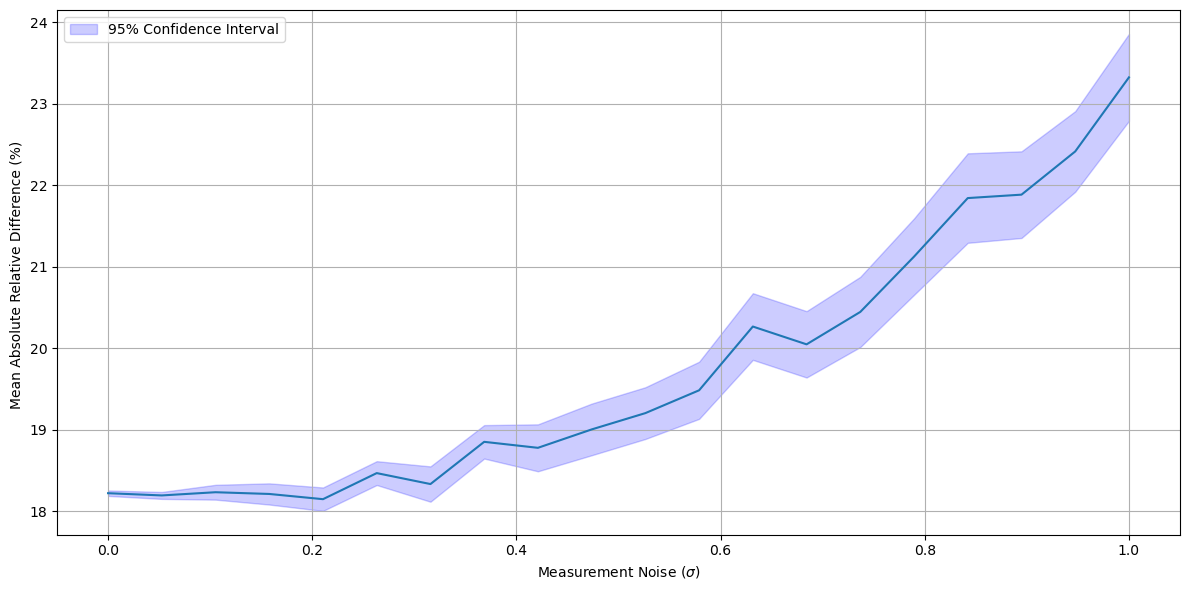

In [9]:
cl = 0.95
ci = np.asarray([scipy.stats.t.interval(confidence=cl, df=num_patients-1, loc=SI_est_mard_mu[sigma], scale=SI_est_mard_std[sigma] / np.sqrt(num_patients)) for sigma in range(num_noise_std)])
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(meas_noise_std, SI_est_mard_mu)
ax.fill_between(meas_noise_std, ci[:,0], ci[:,1], color='blue', alpha=0.2, label='95% Confidence Interval')
ax.set_xlabel(r'Measurement Noise ($\sigma$)')
ax.set_ylabel('Mean Absolute Relative Difference (%) ')
ax.grid()
ax.legend(loc='best')
fig.tight_layout()